# Crocodile Classification - Crocodile Species Dataset 🐊
## Overview

This dataset contains 1,000 field observations of various crocodile species recorded across multiple regions worldwide. Each entry represents a single recorded sighting and includes biological measurements, ecological context, and basic demographic information. The primary goal of this dataset is to support species classification and ecological analysis.

### **Target Variable**
- **Common Name** — The species name used for classification (*Morelet's Crocodile*, *American Crocodile*, etc.).

### **Approach**
Predict the "Common Name" based on measurable traits and environmental attributes.


## Step 1: Loading and Analyzing the dataset

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("crocodile_dataset.csv")
df.head()

Saving crocodile_dataset.csv to crocodile_dataset (1).csv


,Observation ID,Common Name,Scientific Name,Family,Genus,Observed Length (m),Observed Weight (kg),Age Class,Sex,Date of Observation,Country/Region,Habitat Type,Conservation Status,Observer Name,Notes
0,1,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,1.90,62.0,Adult,Male,31-03-2018,Belize,Swamps,Least Concern,Allison Hill,Cause bill scientist nation opportunity.
1,2,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.09,334.5,Adult,Male,28-01-2015,Venezuela,Mangroves,Vulnerable,Brandon Hall,Ago current practice nation determine operatio...
2,3,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,1.08,118.2,Juvenile,Unknown,07-12-2010,Venezuela,Flooded Savannas,Critically Endangered,Melissa Peterson,Democratic shake bill here grow gas enough ana...
3,4,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,2.42,90.4,Adult,Male,01-11-2019,Mexico,Rivers,Least Concern,Edward Fuller,Officer relate animal direction eye bag do.
4,5,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,3.75,269.4,Adult,Unknown,15-07-2019,India,Rivers,Vulnerable,Donald Reid,Class great prove reduce raise author play mov...


In [ ]:
df.shape

(1000, 15)

### **Value Counts for the Target**

In [ ]:
# print value counts for "Common Name" column
print("=" * 40)
print("Value Counts for 'Common Name' Column:".center(40))
print("=" * 40)
print(df["Common Name"].value_counts())

 Value Counts for 'Common Name' Column: 
Common Name
New Guinea Crocodile                         68
Borneo Crocodile (disputed)                  67
American Crocodile                           66
Morelet's Crocodile                          64
Cuban Crocodile                              59
Orinoco Crocodile                            58
Philippine Crocodile                         58
Saltwater Crocodile                          58
West African Dwarf Crocodile                 57
Central African Slender-snouted Crocodile    56
West African Slender-snouted Crocodile       55
West African Crocodile                       52
Hall's New Guinea Crocodile                  49
Congo Dwarf Crocodile                        48
Nile Crocodile                               48
Mugger Crocodile (Marsh Crocodile)           47
Siamese Crocodile                            45
Freshwater Crocodile (Johnstone's)           45
Name: count, dtype: int64


### **Dataset Composition**
**Rows:** 1,000 unique crocodile observations  
**Columns:** 15 descriptive columns

### **Why This Dataset Works Well for Classification**
- The target classes (Common Name) are well-balanced, preventing model bias.
- Numeric features show meaningful variation across species.
- Categorical features provide rich ecological and geographic context.
- Suitable for classification models.

### **Further inspection of usable features and null or missing values**

In [ ]:
# Check for any missing values in each column
missing_values = df.isnull().sum()
print("=" * 40)
print("Missing Values in Each Column:".center(40))
print("=" * 40)
print(missing_values)

     Missing Values in Each Column:     
Observation ID          0
Common Name             0
Scientific Name         0
Family                  0
Genus                   0
Observed Length (m)     0
Observed Weight (kg)    0
Age Class               0
Sex                     0
Date of Observation     0
Country/Region          0
Habitat Type            0
Conservation Status     0
Observer Name           0
Notes                   0
dtype: int64


In [ ]:
# Check types for each column
print("=" * 40)
print("Data Types of Each Column:".center(40))
print("=" * 40)
print(df.dtypes)

       Data Types of Each Column:       
Observation ID            int64
Common Name              object
Scientific Name          object
Family                   object
Genus                    object
Observed Length (m)     float64
Observed Weight (kg)    float64
Age Class                object
Sex                      object
Date of Observation      object
Country/Region           object
Habitat Type             object
Conservation Status      object
Observer Name            object
Notes                    object
dtype: object


### **Now we can drop any columns that are clearly unecessary.**  
In this specific dataset, there are quite a few columns that are unecessary.

In [ ]:
# Checking number of unique values in each column
print("=" * 50)
print("Number of Unique Values in Each Column:".center(50))
print("=" * 50)
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"{column}: {unique_values} unique value(s).")

     Number of Unique Values in Each Column:      
Observation ID: 1000 unique value(s).
Common Name: 18 unique value(s).
Scientific Name: 18 unique value(s).
Family: 1 unique value(s).
Genus: 3 unique value(s).
Observed Length (m): 390 unique value(s).
Observed Weight (kg): 837 unique value(s).
Age Class: 4 unique value(s).
Sex: 3 unique value(s).
Date of Observation: 936 unique value(s).
Country/Region: 47 unique value(s).
Habitat Type: 29 unique value(s).
Conservation Status: 5 unique value(s).
Observer Name: 989 unique value(s).
Notes: 1000 unique value(s).


These columns can be dropped for the following reasons:
- Observation Id: Just a unique identifier for each row.  
- Family: Only has one unique value in the 1000 rows of the dataset.
- Scientific Name: One to one mapping with "Common Name", so this is redundant.
- Genus: Directly tied to species name so using this column would essentially be cheating.
- Date of Observation: No meaningful biological or geographical information.
- Notes: Unstructured and inconsistent strings.
- Observer Name: Says nothing about the crocodile itself. We want to train the models purely based off Biological and Geographical features.
- Consevations Status is too closely related to crocodiles.

In [ ]:
# drop any columns not needed for classification
df = df.drop(columns=["Observation ID", "Scientific Name", "Family", "Date of Observation", "Genus", "Notes", "Observer Name", "Conservation Status"])
df.head()

,Common Name,Observed Length (m),Observed Weight (kg),Age Class,Sex,Country/Region,Habitat Type
0,Morelet's Crocodile,1.90,62.0,Adult,Male,Belize,Swamps
1,American Crocodile,4.09,334.5,Adult,Male,Venezuela,Mangroves
2,Orinoco Crocodile,1.08,118.2,Juvenile,Unknown,Venezuela,Flooded Savannas
3,Morelet's Crocodile,2.42,90.4,Adult,Male,Mexico,Rivers
4,Mugger Crocodile (Marsh Crocodile),3.75,269.4,Adult,Unknown,India,Rivers


### **Now we can assort our data into X and y**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# separate and encode target
le = LabelEncoder()
y = le.fit_transform(df["Common Name"])

# drop target from features
X = df.drop(columns=["Common Name"])

# Use One-hot Encoding for categorical features
X = pd.get_dummies(X)
X.head()

,Observed Length (m),Observed Weight (kg),Age Class_Adult,Age Class_Hatchling,Age Class_Juvenile,Age Class_Subadult,Sex_Female,Sex_Male,Sex_Unknown,Country/Region_Australia,...,Habitat Type_Oxbow Lakes,Habitat Type_Ponds,Habitat Type_Reservoirs,Habitat Type_Rivers,Habitat Type_Shaded Forest Rivers,Habitat Type_Slow Rivers,Habitat Type_Slow Streams,Habitat Type_Small Streams,Habitat Type_Swamps,Habitat Type_Tidal Rivers
0,1.90,62.0,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
1,4.09,334.5,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.08,118.2,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.42,90.4,True,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4,3.75,269.4,True,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False


### **Split the Data into Training and Testing**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 85), (200, 85), (800,), (200,))

In [ ]:
# Scaling data for models that require it
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape

((800, 85), (200, 85))

## **Models To Be Trained**  
### **With Scaling**  
**Logistic Regression**  
Logistic Regression is a linear classification model that estimates the probability of a class using a logistic (sigmoid) function. While this function was designed specifically for binary classification (0 or 1), it can be extended to multi-class problems such as one-vs-rest. It is simple and performs well when relationship between the features and target is roughly linear. Logistic Regression relies on gradient-based optimization, so features need to be on similar scales for the model to converge effectively and avoid giving disproportionate weight to variables with larger numeric ranges

**SVM**  
SVM is a classification algorithm that works by finding the optimal decision boundary that best separates the classes in the feature space. Using kernel functions, SVM can capture non-linear relationships between features, making it effective at distinguishing species when measurements and ecological attributes overlap. SVM performs best when the input features are standardized, so scaling is applied before training.

### **Without Scaling**
**Random Forest**  
Random Forest is an ensemble learning method that builds many decision trees and combines their predictions. Each tree is trained on a random subset of the data and features, which helps reduce overfitting and improve generalization. Random Forests handle both numerical and categorical data well and are strong baseline models for many classification tasks. Random Forest does not require feature scaling because it splits data based on threshold values rather than distance or magnitude, meaning the scale of the inputs does not affect how the trees decide splits.

**XGBoost**  
XGBoost is a powerful gradient boosting algorithm that builds trees sequentially, where each new tree attempts to correct the errors of the previous ones. It includes regularization, efficient handling of missing values, and optimization techniques that make it fast and highly accurate. XGBoost often performs extremely well on structured/tabular data and is commonly used in competitive machine learning. XGBoost also does not require scaling, as it is a tree-based boosting method that evaluates feature importance through split gain rather than absolute feature size, making it insensitive to the scale of input variables.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Training Logisitc Regression Model
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_y_pred = lr_model.predict(X_test_scaled)
lr_accuracy = lr_model.score(X_test_scaled, y_test)

# Training SVM Model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_y_pred = svm_model.predict(X_test_scaled)
svm_accuracy = svm_model.score(X_test_scaled, y_test)

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
rf_accuracy = rf_model.score(X_test, y_test)

# Train XGBoost Model
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)
xgb_accuracy = xgb_model.score(X_test, y_test)

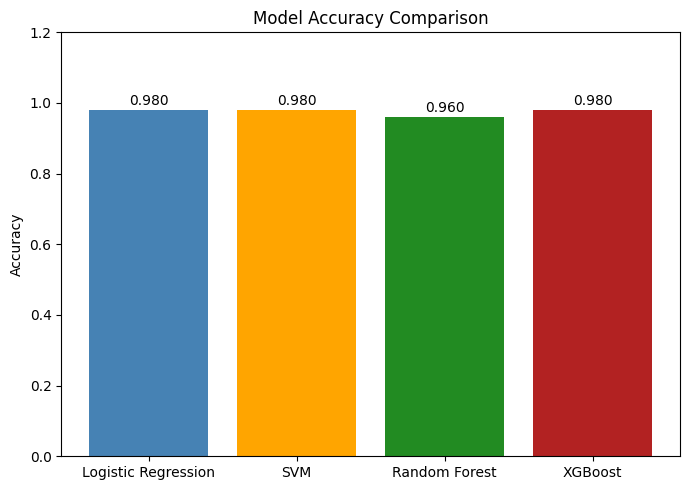

In [ ]:
import matplotlib.pyplot as plt
# Compare performance of all models
accuracies = {
    "Logistic Regression": lr_accuracy,
    "SVM": svm_accuracy,
    "Random Forest": rf_accuracy,
    "XGBoost": xgb_accuracy
}

def plot_model_accuracies(acc_dict):
    names = list(acc_dict.keys())
    values = list(acc_dict.values())

    plt.figure(figsize=(7, 5))
    bars = plt.bar(names, values, color=['steelblue', 'orange', 'forestgreen', 'firebrick'])

    # Annotate bars with the numeric accuracy value
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, value + 0.005, f"{value:.3f}",
                 ha='center', va='bottom', fontsize=10)

    plt.ylim(0, 1.2)
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy Comparison")
    plt.tight_layout()
    plt.show()

plot_model_accuracies(accuracies)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support as score

def evaluation(model_type, y_test, y_pred):
    print('=' * 60)
    print(f'Evaluation of {model_type} Model'.center(60))
    print('=' * 60)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, fscore, support = score(y_test, y_pred, average='macro')

    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"FScore: {fscore}")
    print("\n")

In [ ]:
# Evaluation of Each Model
evaluation("Logistic Regression", y_test, lr_y_pred)
evaluation("SVM", y_test, svm_y_pred)
evaluation("Random Forest", y_test, rf_y_pred)
evaluation("XGBoost", y_test, xgb_y_pred)

          Evaluation of Logistic Regression Model           
Accuracy: 0.98
Precision: 0.9796296296296296
Recall: 0.9832516339869282
FScore: 0.98070987654321


                  Evaluation of SVM Model                   
Accuracy: 0.98
Precision: 0.9814814814814814
Recall: 0.9869281045751634
FScore: 0.9814814814814815


             Evaluation of Random Forest Model              
Accuracy: 0.96
Precision: 0.9631335282651072
Recall: 0.9712117303061576
FScore: 0.9633017729508957


                Evaluation of XGBoost Model                 
Accuracy: 0.98
Precision: 0.979131593714927
Recall: 0.9803467683369644
FScore: 0.9792320968791558




In [ ]:
# Classification Report For each model
from sklearn.metrics import classification_report

def class_report(model_type, y_test, y_pred):
    print('=' * 82)
    print(f'Class Evaluation for {model_type} Model'.center(82))
    print('=' * 82)

    target_names = le.classes_
    matrix = classification_report(y_test, y_pred, target_names=target_names)
    print(matrix)

class_report("Logistic Regression", y_test, lr_y_pred)
class_report("SVM", y_test, svm_y_pred)
class_report("Random Forest", y_test, rf_y_pred)
class_report("XGBoost", y_test, xgb_y_pred)

                  Class Evaluation for Logistic Regression Model                  
                                           precision    recall  f1-score   support

                       American Crocodile       1.00      1.00      1.00        19
              Borneo Crocodile (disputed)       1.00      1.00      1.00         7
Central African Slender-snouted Crocodile       1.00      1.00      1.00        11
                    Congo Dwarf Crocodile       1.00      1.00      1.00         9
                          Cuban Crocodile       1.00      1.00      1.00        17
       Freshwater Crocodile (Johnstone's)       1.00      1.00      1.00         9
              Hall's New Guinea Crocodile       0.70      0.88      0.78         8
                      Morelet's Crocodile       1.00      1.00      1.00        17
       Mugger Crocodile (Marsh Crocodile)       1.00      1.00      1.00         8
                     New Guinea Crocodile       0.93      0.82      0.88        17
   